# Q-Learning

**O código é inspirado no tutorial sobre Q-Learning do Thomas Simonini [Link do Tutorial](https://huggingface.co/blog/deep-rl-q-part2)**

## Configurando a visualização em vídeo
Para gerar um vídeo de repetição do agente e do ambiente.


In [1]:
%%capture
!pip install pyglet==1.5.1
!apt install python-opengl
!apt install ffmpeg
!apt install xvfb
!pip3 install pyvirtualdisplay

# Virtual display
from pyvirtualdisplay import Display

virtual_display = Display(visible=0, size=(1400, 900))
virtual_display.start()

## Instalando  dependências

In [2]:
%%capture
!pip install pygame
!pip install imageio imageio_ffmpeg

## Importando os módulos

In [3]:
import numpy as np
import gymnasium as gym
import random
import imageio
from tqdm.notebook import trange

## Frozen Lake

Versão deterministíca (is_slippery=False)

In [4]:
# Criando o ambiente FrozenLake-v1 usando mapa 4x4 e versão não escorregadio
env = gym.make("FrozenLake-v1",map_name="4x4",is_slippery=False, render_mode="rgb_array")

array([[[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]],

       [[180, 200, 230],
        [204, 230, 255],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       ...,

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [235, 245, 249],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]]], dtype=uint8)
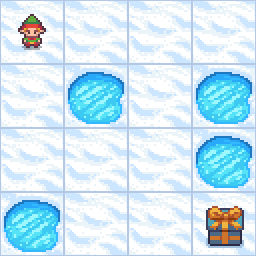

In [5]:
env.reset()
env.render()

### Compreendendo o ambiente FrozenLake

In [6]:
print("_____ESPAÇO DE OBSERVAÇÃO_____ \n")
print("Espaço de Observação", env.observation_space)
print("Amostra de uma observação", env.observation_space.sample()) # Pegar uma observação aleatória

_____ESPAÇO DE OBSERVAÇÃO_____ 

Espaço de Observação Discrete(16)
Amostra de uma observação 5


In [7]:
print("\n _____ESPAÇO DE AÇÃO_____ \n")
print("Espaço de ação", env.action_space.n)
print("Amostra de espaço de ação", env.action_space.sample()) # Tomar uma ação aleatória


 _____ESPAÇO DE AÇÃO_____ 

Espaço de ação 4
Amostra de espaço de ação 0


## Criando e inicializando uma Q-Table

In [8]:
state_space = env.observation_space.n
print("Existem ", state_space, " estados possíveis")

action_space = env.action_space.n
print("Existem ", action_space, " ações possíveis")

Existem  16  estados possíveis
Existem  4  ações possíveis


In [9]:
# Vamos criar nossa Qtable de tamanho (state_space, action_space) e inicializar cada valor em 0 usando np.zeros
def initialize_q_table(state_space, action_space):
    Qtable = np.zeros((state_space, action_space))
    return Qtable

In [10]:
Qtable_frozenlake = initialize_q_table(state_space, action_space)

In [11]:
Qtable_frozenlake

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [12]:
Qtable_frozenlake.shape

(16, 4)

## Definindo a política epsilon-greedy


In [13]:
def epsilon_greedy_policy(Qtable, state, epsilon):
    # Gere aleatoriamente um número entre 0 e 1
    random_int = random.uniform(0,1)
    # Se random é maior que epsilon --> exploitation (fazer uma ação baseada na experiência)
    if random_int > epsilon:
        # Execute a ação com o valor mais alto dado um estado
        # np.argmax can be useful here
        action = np.argmax(Qtable[state])
      # else --> exploration (fazer uma ação aleatória para avaliar novos ações)
    else:
       action = env.action_space.sample()

    return action

## Definindo a política greedy

In [14]:
def greedy_policy(Qtable, state):
    # Exploitation: executa a ação com o estado e valor de ação mais alto (ganacioso)
    action = np.argmax(Qtable[state])

    return action

## Configurar os hiperparâmetros

In [15]:
# Parâmetros de treinamento
n_training_episodes = 10000  # Total de episódios de treinamento
learning_rate = 0.7          # Taxa de aprendizagem

# Parâmetros de avaliação
n_eval_episodes = 100        # Número total de episódios de teste

# Parâmetros do Environment
env_id = "FrozenLake-v1"     # Nome do environment
max_steps = 20               # Máximo de passos por episódio
gamma = 0.95                 # Taxa de desconto
eval_seed = []               # A semente de avaliação do meio ambiente

# Parâmetros de exploração
max_epsilon = 1.0             # Probabilidade de exploração no início
min_epsilon = 0.05            # Probabilidade mínima de exploração
decay_rate = 0.0005           # Taxa de decaimento exponencial para problema de exploração

## Treinando o modelo

In [16]:
def train_qlearning(n_training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, Qtable):
    for episode in trange(n_training_episodes):
      # Reduzir o epsilon (porque precisamos cada vez menos de exploração)
      epsilon = min_epsilon + (max_epsilon - min_epsilon)*np.exp(-decay_rate*episode)
      # Redefinir o ambiente
      state, info = env.reset()
      step = 0
      done = False

      # Laço
      for step in range(max_steps):
          # Escolha a ação ao usar a política epsilon greedy
          action = epsilon_greedy_policy(Qtable, state, epsilon)

          # Tomar a ação At e obtem Rt+1 e St+1
          # Executar a ação (a) e obtem o estado (s') e a recompensa (r)
          new_state, reward, done, truncated, info = env.step(action)

          # Atualizar Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
          Qtable[state][action] = Qtable[state][action] + learning_rate * (reward + gamma * np.max(Qtable[new_state]) - Qtable[state][action])

          # Se done ou truncated são verdadeiros, termine o episódio
          if done or truncated:
              break

          # O estado atual é atualizado pelo novo estado
          state = new_state
    return Qtable

In [17]:
Qtable_frozenlake = train_qlearning(n_training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, Qtable_frozenlake)

  0%|          | 0/10000 [00:00<?, ?it/s]

## Tabela Q-Learning treinada

In [18]:
#Ações disponíveis
#0: Move left
#1: Move down
#2: Move right
#3: Move up
Qtable_frozenlake

array([[0.73509189, 0.77378094, 0.77378094, 0.73509189],
       [0.73509189, 0.        , 0.81450625, 0.77378094],
       [0.77378094, 0.857375  , 0.77378094, 0.81450625],
       [0.81450625, 0.        , 0.77378094, 0.77378094],
       [0.77378094, 0.81450625, 0.        , 0.73509189],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.9025    , 0.        , 0.81450625],
       [0.        , 0.        , 0.        , 0.        ],
       [0.81450625, 0.        , 0.857375  , 0.77378094],
       [0.81450625, 0.9025    , 0.9025    , 0.        ],
       [0.857375  , 0.95      , 0.        , 0.857375  ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.9025    , 0.95      , 0.857375  ],
       [0.9025    , 0.95      , 1.        , 0.9025    ],
       [0.        , 0.        , 0.        , 0.        ]])

## Avaliação do modelo

In [19]:
def evaluate_agent(env, max_steps, n_eval_episodes, Q, seed):
    """
    Evaluate the agent for ``n_eval_episodes`` episodes and returns average reward and std of reward.
    :param env: The evaluation environment
    :param n_eval_episodes: Number of episode to evaluate the agent
    :param Q: The Q-table
    :param seed: The evaluation seed array (for taxi-v3)
    """
    episode_rewards = []
    for episode in range(n_eval_episodes):
        if seed:
            state, _ = env.reset(seed=seed[episode])
        else:
            state, _ = env.reset()
        step = 0
        done = False
        total_rewards_ep = 0

        for step in range(max_steps):
            # Tome a ação (índice) que tem a recompensa futura máxima esperada dado esse estado
            action = np.argmax(Q[state][:]) #Não preciso explorar (aleatoriamente)
            new_state, reward, done, truncated, info = env.step(action) # Fixed: include truncated
            total_rewards_ep += reward

            if done or truncated:
                break
            state = new_state
        episode_rewards.append(total_rewards_ep)
    mean_reward = np.mean(episode_rewards)
    std_reward = np.std(episode_rewards)

    return mean_reward, std_reward

In [20]:
# Avaliar o Agente
mean_reward, std_reward = evaluate_agent(env, max_steps, n_eval_episodes, Qtable_frozenlake, eval_seed)
print(f"Recompensa Média = {mean_reward:.2f} +/- {std_reward:.2f}")

Recompensa Média = 1.00 +/- 0.00


## Visualizando os resultados

In [21]:
def record_video(env, Qtable, out_directory, fps=1):
    images = []
    done = False
    state, _ = env.reset(seed=random.randint(0,500)) # Fixed: extract observation
    img = env.render()
    images.append(img)
    while not done:
        # Take the action (index) that have the maximum expected future reward given that state
        action = greedy_policy(Qtable, state)
        state, reward, done, truncated, info = env.step(action) # Fixed: include truncated
        img = env.render()
        images.append(img)
    imageio.mimsave(out_directory, [np.array(img) for i, img in enumerate(images)], fps=fps)

Salvando arquivo animado como GIF com 1 quadro por segundo

In [22]:
video_path="/content/replay_qlearning.gif"
video_fps=1

In [23]:
record_video(env, Qtable_frozenlake, video_path, video_fps)

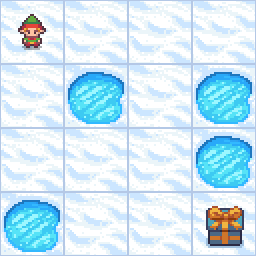

In [24]:
from IPython.display import Image
Image('./replay_qlearning.gif')

# Frozen Lake escorregadio



In [25]:
# Parâmetros de treinamento
n_training_episodes = 15000      # Mais episódios para convergir
learning_rate = 0.1              # Menor para estabilidade

# Parâmetros de avaliação
n_eval_episodes = 100        # Número total de episódios de teste

# Parâmetros do Environment
env_id = "FrozenLake-v1"     # Nome do environment
max_steps = 99                   # Padrão do Gymnasium
gamma = 0.99                     # Maior para valorizar recompensas futuras
eval_seed = []               # A semente de avaliação do meio ambiente

# Parâmetros de exploração
max_epsilon = 1.0
min_epsilon = 0.01               # Sempre manter alguma exploração
decay_rate = 0.001               # Decaimento mais rápido

In [26]:
Qtable_frozenlake_slippery = initialize_q_table(state_space, action_space)

In [27]:
env_slippery = gym.make("FrozenLake-v1",map_name="4x4",is_slippery=True, render_mode="rgb_array")

In [28]:
Qtable_frozenlake_slippery = train_qlearning(n_training_episodes, min_epsilon, max_epsilon, decay_rate, env_slippery, max_steps, Qtable_frozenlake_slippery)

  0%|          | 0/15000 [00:00<?, ?it/s]

In [29]:
# Avaliar o Agente
mean_reward, std_reward = evaluate_agent(env_slippery, max_steps, n_eval_episodes, Qtable_frozenlake_slippery, eval_seed)
print(f"Recompensa Média = {mean_reward:.2f} +/- {std_reward:.2f}")

Recompensa Média = 0.72 +/- 0.45


In [30]:
video_path_slippery="/content/replay_qlearning_slippery.gif"
video_fps=1

In [31]:
record_video(env_slippery, Qtable_frozenlake_slippery, video_path_slippery, video_fps)

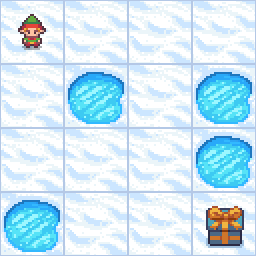

In [32]:
from IPython.display import Image
Image('./replay_qlearning_slippery.gif')

Simulação
https://imgur.com/a/nj461qf

Por que funciona?

- Learning rate baixo: Permite convergência gradual mesmo com ruído estocástico
- Mais episódios: Necessário para explorar todas as transições estocásticas
- Gamma alto (0.99): Valoriza trajetórias longas até o goal
- Decay adequado: Balanceia exploração inicial e exploitation final


O FrozenLake slippery pode alcançar ~70-75% de taxa de sucesso no melhor caso devido à natureza estocástica do ambiente.

